In [19]:
import sys
import os
import psycopg2
from dotenv import load_dotenv

sys.path.append(os.path.abspath(".."))

load_dotenv()
url = os.getenv("DATABASE_URL")

In [20]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [21]:
query = """
SELECT 
    ticker,
    CASE 
        WHEN EXTRACT(DOW FROM MAX(timestamp)) = 3 THEN MAX(timestamp)
        ELSE NULL
    END AS expiry_date
FROM orderbooks
GROUP BY ticker
"""
cur.execute(query)
rows = cur.fetchall()

data = {ticker: expiry for ticker, expiry in rows}
tickers = [ticker for ticker, date in data.items()]

In [22]:
from datetime import datetime, timezone

#sorted by expiry dates
data = dict(sorted(data.items(), key=lambda item: item[1] if item[1] is not None else datetime(2099,1,1, tzinfo=timezone.utc)))

In [23]:
expiry_dates = [date.replace(hour=0, minute=0, second=0, microsecond=0) for ticker, date in data.items() if date is not None]
unique_dates = list(dict.fromkeys(expiry_dates))
print(unique_dates)

[datetime.datetime(2026, 3, 25, 0, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 4, 1, 0, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 4, 8, 0, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 4, 15, 0, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 4, 22, 0, 0, tzinfo=datetime.timezone.utc), datetime.datetime(2026, 4, 29, 0, 0, tzinfo=datetime.timezone.utc)]


In [24]:
import pandas as pd

def compute_price(bid, ask):
    if bid is not None and ask is not None:
        return (bid + ask) / 2
    elif bid is not None:
        return bid
    elif ask is not None:
        return ask
    else:
        return None

results = []
for date in unique_dates:
    
    #not expiring this day 
    not_expiring_tickers = [ticker for ticker, expiry_date in data.items() 
                             if (expiry_date != None and expiry_date.replace(hour=0, minute=0, second=0, microsecond=0) > date)  
                             or expiry_date == None]

    query = """
        SELECT * FROM (
            (
                SELECT DISTINCT ON (ticker) *
                FROM orderbooks
                WHERE timestamp >= %s AND timestamp < %s + INTERVAL '1 day'
                AND ticker = ANY(%s)
                ORDER BY ticker, 
                ABS(EXTRACT(EPOCH FROM (timestamp - (%s + INTERVAL '8 hour'))))
            )
            UNION ALL
            (
                SELECT DISTINCT ON (ticker) *
                FROM orderbooks
                WHERE timestamp >= %s AND timestamp < %s + INTERVAL '1 day'
                AND ticker = ANY(%s)
                ORDER BY ticker, 
                ABS(EXTRACT(EPOCH FROM (timestamp - (%s + INTERVAL '20 hour'))))
            )
        ) AS combined
        ORDER BY ticker, timestamp;
        """

    cur.execute( query, (date, date, not_expiring_tickers, date, date, date, not_expiring_tickers, date))
    rows = cur.fetchall()

    col_names = [desc[0] for desc in cur.description]
    df = pd.DataFrame(rows, columns=col_names)


    
    df_first = df.groupby('ticker').first().reset_index()  
    df_last = df.groupby('ticker').last().reset_index()
    df = df_first.merge(df_last, on='ticker', suffixes=('_first', '_last'))

    best_bid_first = df['bids_first'].apply(lambda x: max(x, key=lambda y: y['price'])['price'] if x else None)
    best_ask_first = df['asks_first'].apply(lambda x: min(x, key=lambda y: y['price'])['price'] if x else None)
    best_bid_last = df['bids_last'].apply(lambda x: max(x, key=lambda y: y['price'])['price'] if x else None)
    best_ask_last = df['asks_last'].apply(lambda x: min(x, key=lambda y: y['price'])['price'] if x else None)

    mid_price_first = pd.Series(map(compute_price, best_bid_first, best_ask_first),index=df.index)
    mid_price_last = pd.Series(map(compute_price, best_bid_last, best_ask_last),index=df.index)

    mid_price_returns = (mid_price_last - mid_price_first) / mid_price_first

    df['date'] = date
    for idx, ticker in enumerate(df['ticker']):
        results.append({
            'date': date,
            'ticker': ticker,
            'mid_price_first': mid_price_first.iloc[idx],
            'mid_price_last': mid_price_last.iloc[idx],
            'mid_price_returns': mid_price_returns.iloc[idx]
        })

    
final_df = pd.DataFrame(results)
print(final_df.head())

                       date     ticker  mid_price_first  mid_price_last  \
0 2026-03-25 00:00:00+00:00   SR270CD6           50.305          49.085   
1 2026-03-25 00:00:00+00:00  SR270CD6A              NaN             NaN   
2 2026-03-25 00:00:00+00:00   SR270CP6              NaN             NaN   
3 2026-03-25 00:00:00+00:00  SR270CP6A              NaN             NaN   
4 2026-03-25 00:00:00+00:00   SR280CD6           40.635          39.835   

   mid_price_returns  
0          -0.024252  
1                NaN  
2                NaN  
3                NaN  
4          -0.019687  


In [25]:
final_df['strike'] = final_df['ticker'].str[2:5].astype(int)
final_df['option_type'] = final_df['ticker'].apply(lambda x: 'P' if 'CP' in x else 'C')

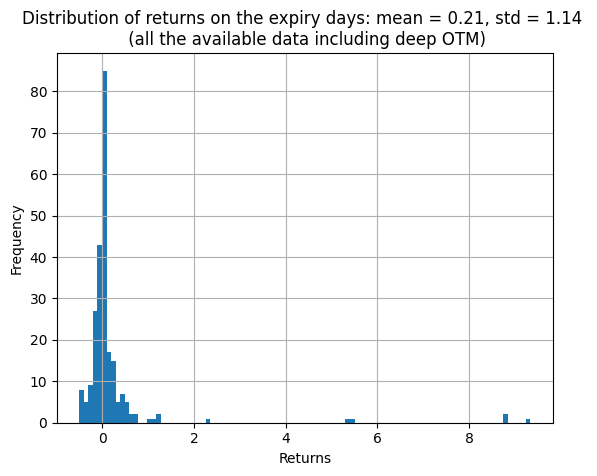

In [26]:
returns = final_df['mid_price_returns'].dropna()

from matplotlib import pyplot as plt
plt.hist(returns, bins=100)
plt.title(F"Distribution of returns on the expiry days: mean = {returns.mean():.2F}, std = {returns.std():.2F} \n (all the available data including deep OTM)")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

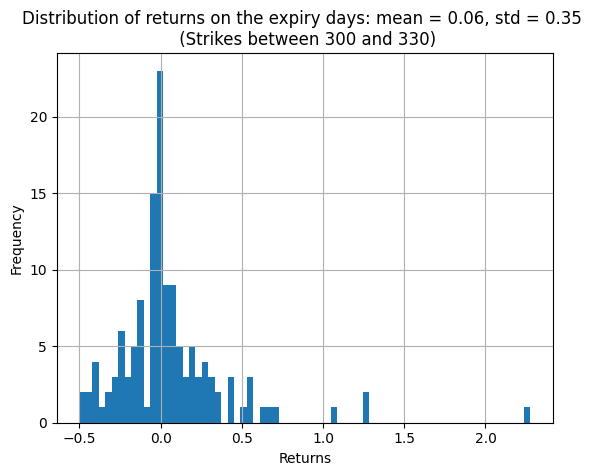

In [27]:
filtered_df = final_df[final_df['strike'].between(300, 330)] #only ATM/ slightly OTM
filtered_returns = filtered_df['mid_price_returns'].dropna()

plt.hist(filtered_returns, bins=70)
plt.title(F"Distribution of returns on the expiry days: mean = {filtered_returns.mean():.2F}, std = {filtered_returns.std():.2F} \n (Strikes between 300 and 330)")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [28]:
calls_df = final_df[final_df['option_type'] == 'C']
puts_df  = final_df[final_df['option_type'] == 'P']

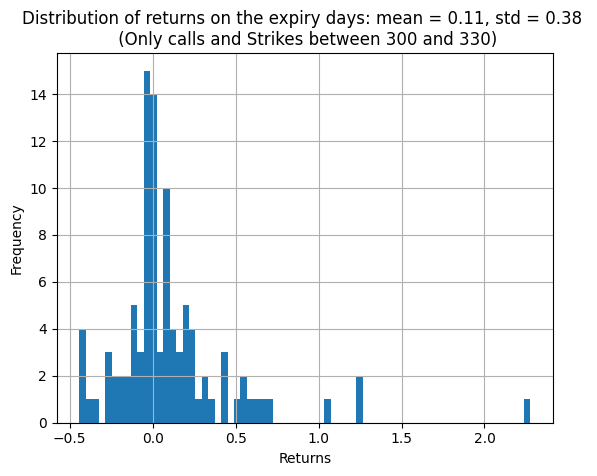

In [29]:
filtered_calls_df = calls_df[calls_df['strike'].between(300, 330)] #only ATM/ slightly OTM
filtered_calls_returns = filtered_calls_df['mid_price_returns'].dropna()

plt.hist(filtered_calls_returns, bins=70)
plt.title(F"Distribution of returns on the expiry days: mean = {filtered_calls_returns.mean():.2F}, std = {filtered_calls_returns.std():.2F} \n (Only calls and Strikes between 300 and 330)")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

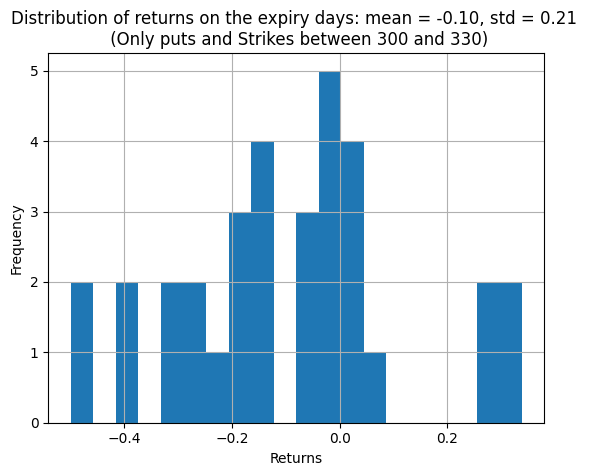

In [30]:
filtered_puts_df = puts_df[puts_df['strike'].between(300, 330)] #only ATM/ slightly OTM
filtered_puts_returns = filtered_puts_df['mid_price_returns'].dropna()

plt.hist(filtered_puts_returns, bins=20)
plt.title(F"Distribution of returns on the expiry days: mean = {filtered_puts_returns.mean():.2F}, std = {filtered_puts_returns.std():.2F} \n (Only puts and Strikes between 300 and 330)")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.grid()
plt.show()

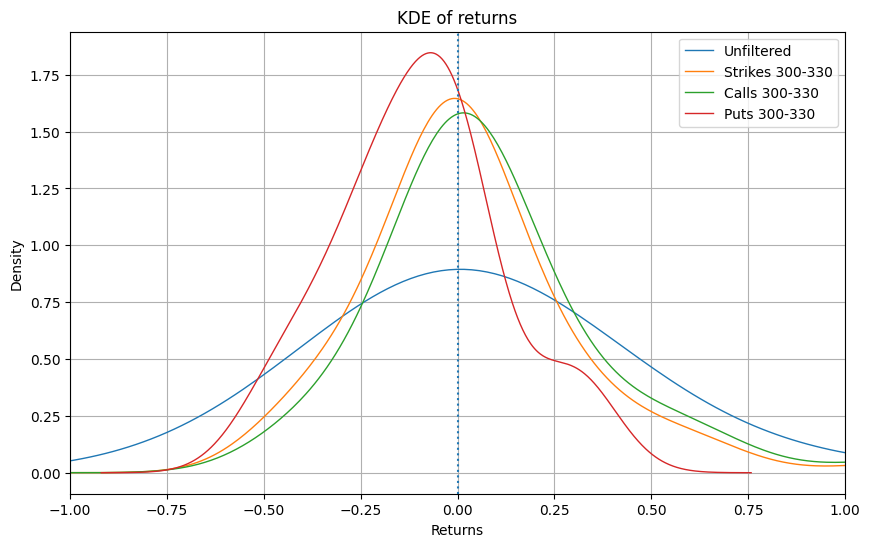

In [31]:
plt.figure(figsize=(10, 6))

returns.plot(kind='kde', label="Unfiltered", linewidth=1)
filtered_returns.plot(kind='kde', label="Strikes 300-330", linewidth=1)
filtered_calls_returns.plot(kind='kde', label="Calls 300-330", linewidth=1)
filtered_puts_returns.plot(kind='kde', label="Puts 300-330", linewidth=1)

plt.title("KDE of returns")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.xlim(-1, 1)
plt.axvline(0, linestyle=':') 
plt.grid()
plt.legend()
plt.show()

Text(0.5, 1.0, 'Simplest backtest (fee = 2.5%, mid prices are used)')

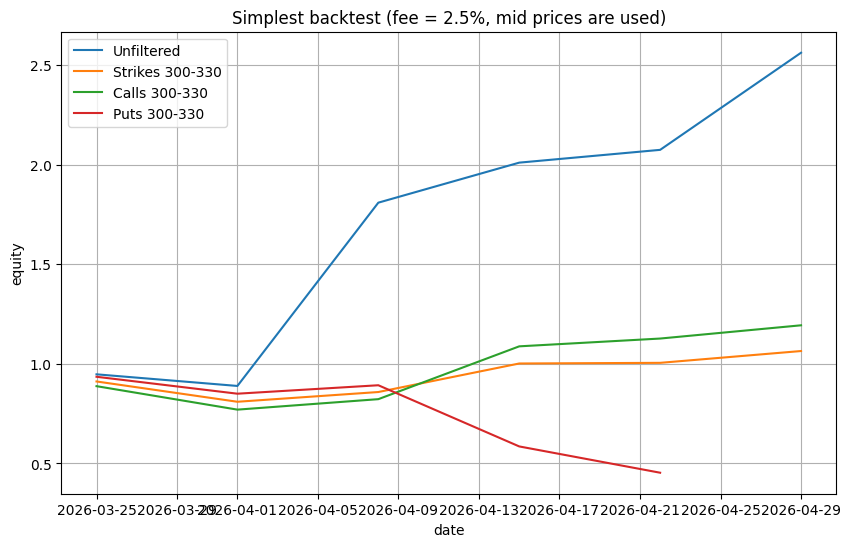

In [32]:
plt.figure(figsize=(10, 6))
fee = 0.025

df = final_df.dropna(subset=['mid_price_returns']).copy()
daily_returns = df.groupby('date')['mid_price_returns'].mean()
daily_returns = daily_returns - fee
equity = (1 + daily_returns).cumprod()
plt.plot(equity.index, equity, label="Unfiltered")

df = filtered_df.dropna(subset=['mid_price_returns']).copy()
daily_returns = df.groupby('date')['mid_price_returns'].mean()
daily_returns = daily_returns - fee
equity = (1 + daily_returns).cumprod()
plt.plot(equity.index, equity, label="Strikes 300-330")

df = filtered_calls_df.dropna(subset=['mid_price_returns']).copy()
daily_returns = df.groupby('date')['mid_price_returns'].mean()
daily_returns = daily_returns - fee
equity = (1 + daily_returns).cumprod()
plt.plot(equity.index, equity, label="Calls 300-330")

df = filtered_puts_df.dropna(subset=['mid_price_returns']).copy()
daily_returns = df.groupby('date')['mid_price_returns'].mean()
daily_returns = daily_returns - fee
equity = (1 + daily_returns).cumprod()
plt.plot(equity.index, equity, label="Puts 300-330")

plt.legend()
plt.grid()
plt.xlabel("date")
plt.ylabel("equity")
plt.title(f"Simplest backtest (fee = {fee*100}%, mid prices are used)")